# English-language fandom decomposition (PRD §9.17)

**Purpose:** Twitch's `language` field tags 52%/22% of Apex Legends'/
PUBG: BATTLEGROUNDS' viewers as `en` with no way to tell a US, UK,
Indian, Filipino, Canadian, or Australian audience apart
(`notebooks/niche_membership.ipynb`'s Apex/PUBG shared-occupancy finding,
2026-09-12). This notebook runs the reusable subsystem built to fix that
-- `analysis/fandom_region_decomposition.py` -- against every subject
configured in `config/fandom_decomposition_subjects.yaml`, not a
one-off for this one pair. "Fandom," not "viewership": several
independent signals are shown side by side (Twitch viewership,
self-declared stream tags, Wikipedia pageviews, Steam reviews), never
collapsed into one number -- the same "three metrics side by side"
convention `niche_membership.ipynb` already established.

Three subjects prove three different things: `apex_legends`/`pubg` are
the motivating pair; `gta_v` proves the platform-wide (`game_id`-keyed,
not `title_id`-keyed) path works, for `docs/wider_game_fandom_brief.md`;
`counter_strike` cross-checks the Steam-review timezone signal against
`notebooks/fastest_growing_cs_regions.ipynb`'s independently-derived
grassroots-tournament regional growth.

In [1]:
import sys
from pathlib import Path

def _find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "CLAUDE.md").is_file():
            return candidate
    raise RuntimeError("Could not find repo root (CLAUDE.md not found in any parent directory) -- run this notebook from somewhere inside the repo")

REPO_ROOT = _find_repo_root(Path.cwd())
sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from etl.db import get_connection
from analysis.fandom_region_decomposition import (
    CANDIDATE_ENGLISH_COUNTRIES,
    calibrate_timezone_curve,
    decompose_by_timezone,
    get_steam_review_hourly_series,
    get_twitch_english_hourly_series,
    load_subjects,
)

SUBJECT_IDS = ["apex_legends", "pubg", "counter_strike", "gta_v"]
subjects = load_subjects()
conn = get_connection()
calibration_curve = calibrate_timezone_curve(conn)
calibration_curve

array([0.04179583, 0.02162894, 0.02778875, 0.04677054, 0.        ,
       0.01291902, 0.01633136, 0.0021953 , 0.03370971, 0.00631066,
       0.01160364, 0.        , 0.03495026, 0.22493425, 0.00646346,
       0.        , 0.00717838, 0.03644304, 0.08348036, 0.03959169,
       0.        , 0.04673028, 0.13493677, 0.16423776])

## Signal 1 -- Twitch English viewer-time, timezone-deconvolved

Calibrated against `ja`/`ko` (Japan/Korea, UTC+9, single-timezone,
no-DST anchors -- see `analysis/fandom_region_decomposition.py`'s module
docstring for why `ru`/`de`/`fr`/`pt` are deliberately excluded from
calibration despite being usable for coarse region-tagging elsewhere).

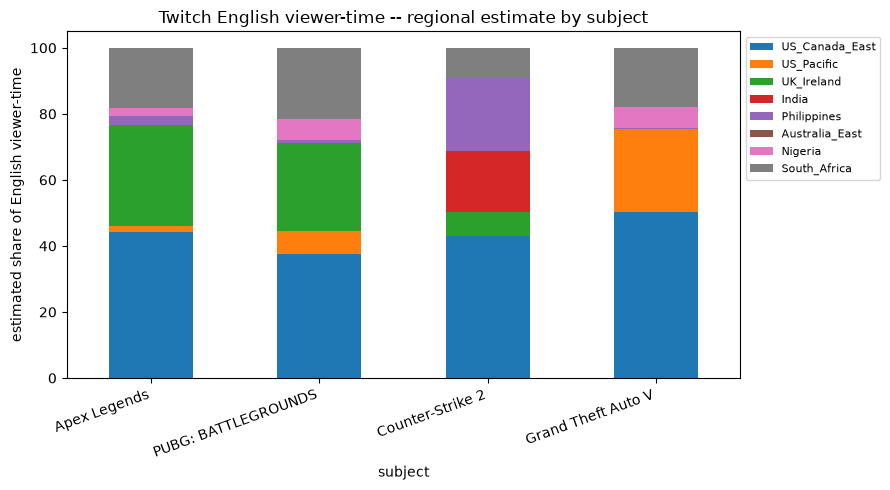

,total_english_viewer_time,US_Canada_East,US_Pacific,UK_Ireland,India,Philippines,Australia_East,Nigeria,South_Africa
subject,,,,,,,,,
Apex Legends,919931,44.1,1.9,30.7,0.0,2.7,0.0,2.4,18.2
PUBG: BATTLEGROUNDS,176887,37.5,6.9,26.8,0.0,1.0,0.0,6.1,21.7
Counter-Strike 2,1419430,42.9,0.0,7.4,18.6,21.9,0.0,0.0,9.2
Grand Theft Auto V,1682715,50.3,25.2,0.0,0.0,0.3,0.0,6.4,17.8


In [2]:
twitch_rows = []
for subject_id in SUBJECT_IDS:
    subject = subjects[subject_id]
    hourly = get_twitch_english_hourly_series(conn, subject)
    total_english_viewer_time = int(hourly.sum())
    shares = decompose_by_timezone(hourly, calibration_curve=calibration_curve)
    row = {"subject": subject["display_name"], "total_english_viewer_time": total_english_viewer_time}
    row.update({country: round(share * 100, 1) for country, share in shares.items()})
    twitch_rows.append(row)

twitch_df = pd.DataFrame(twitch_rows).set_index("subject")

fig, ax = plt.subplots(figsize=(9, 5))
twitch_df.drop(columns="total_english_viewer_time").fillna(0).plot(kind="bar", stacked=True, ax=ax)
ax.set_ylabel("estimated share of English viewer-time")
ax.set_title("Twitch English viewer-time -- regional estimate by subject")
ax.legend(fontsize=8, loc="upper left", bbox_to_anchor=(1.0, 1.0))
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()
twitch_df

## Signal 2 -- self-declared region tags (`etl/extract_stream_region_tags.py`)

A completely different mechanism from timezone deconvolution -- a
streamer or their tournament organizer explicitly labeling a region in
the stream's own tags/title (`NA`/`EU`/`OCE`/... -- see that script's
module docstring for the real-data-validated whitelist, and why `BR` is
deliberately excluded as ambiguous between "Brazil" and "Battle
Royale"). Sparse by nature -- most streams declare no region at all --
so shown as counts, not shares, and only among each subject's own
`en`-language rows.

In [3]:
tag_rows = []
for subject_id in SUBJECT_IDS:
    subject = subjects[subject_id]
    if subject["source_table"] == "viewership_snapshots":
        query = "SELECT self_declared_region_tag, COUNT(*) FROM viewership_snapshots WHERE title_id = ? AND language = 'en' AND self_declared_region_tag IS NOT NULL GROUP BY self_declared_region_tag"
        params = (subject["title_id"],)
    else:
        query = "SELECT self_declared_region_tag, COUNT(*) FROM platform_viewership_snapshots WHERE game_id = ? AND language = 'en' AND self_declared_region_tag IS NOT NULL GROUP BY self_declared_region_tag"
        params = (subject["game_id"],)
    counts = dict(conn.execute(query, params).fetchall())
    tag_rows.append({"subject": subject["display_name"], **counts})

tag_df = pd.DataFrame(tag_rows).set_index("subject").fillna(0).astype(int)
tag_df

,APAC,EU,LATAM,NA,OCE,SEA,UK,MENA
subject,,,,,,,,
Apex Legends,5,27,14,46,116,24,170,0
PUBG: BATTLEGROUNDS,0,6,0,33,52,2,58,1
Counter-Strike 2,1,35,2,55,96,4,115,3
Grand Theft Auto V,0,6,0,9,62,0,127,0


## Signal 3 -- Wikipedia article pageviews

**Correction made while building this notebook, not assumed going in:**
the public Wikimedia Pageviews API's per-article granularity is `daily`
only -- there is no hourly breakdown, so `decompose_by_timezone`'s
hour-of-day method genuinely cannot be applied to this signal (the
"diurnal-pattern correlation" originally scoped for it isn't buildable
against this API). Wikipedia pageviews' real contribution here is as an
independent fandom-engagement signal in its own right -- reading about a
game vs. watching it streamed -- shown as its own trend, not folded into
the region question.

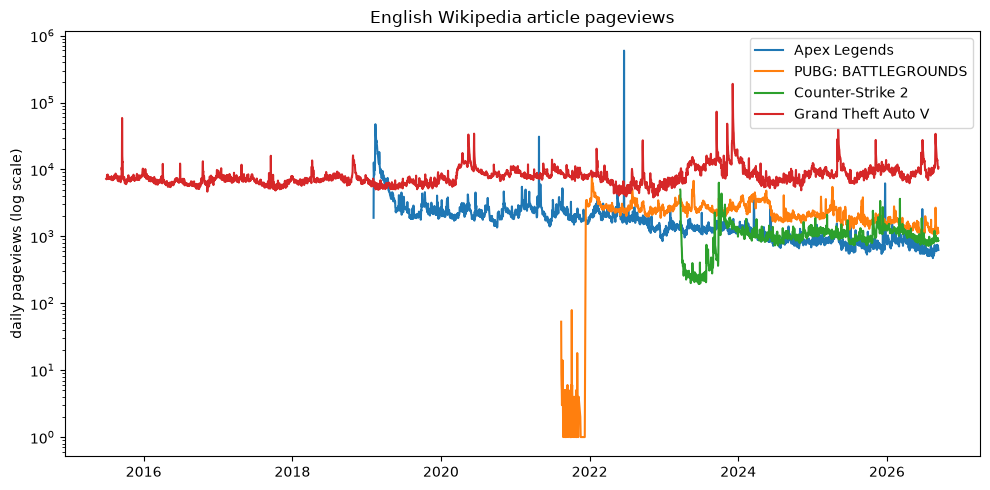

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
for subject_id in SUBJECT_IDS:
    rows = conn.execute(
        "SELECT date, views FROM wikipedia_pageview_snapshots WHERE subject_id = ? ORDER BY date",
        (subject_id,),
    ).fetchall()
    if not rows:
        print(f"[info] {subject_id}: no Wikipedia pageview data")
        continue
    dates = pd.to_datetime([r[0] for r in rows], format="%Y%m%d")
    views = [r[1] for r in rows]
    ax.plot(dates, views, label=subjects[subject_id]["display_name"])
ax.set_yscale("log")
ax.set_ylabel("daily pageviews (log scale)")
ax.set_title("English Wikipedia article pageviews")
ax.legend()
plt.tight_layout()
plt.show()

## Signal 4 -- Steam review-language, and review-posting-time deconvolution

**Honest status, not overstated:** `collectors/steam_review_history_pull.py`
was smoke-tested against real data (confirmed working end-to-end) but a
full crawl has NOT been run -- Apex Legends alone has 1M+ reviews, and a
full historical crawl for even one subject is a multi-hour-to-multi-day
background job, the same category of task as `collectors/
steam_catalog_backfill.py`'s own "expect 1-2 weeks" Track A backfill.
`steam_review_history` currently holds only a ~100-review smoke-test
sample for `apex_legends` and nothing for the other subjects. Everything
below is a proof that the pipeline works, not a result to cite --
re-run after a real crawl.

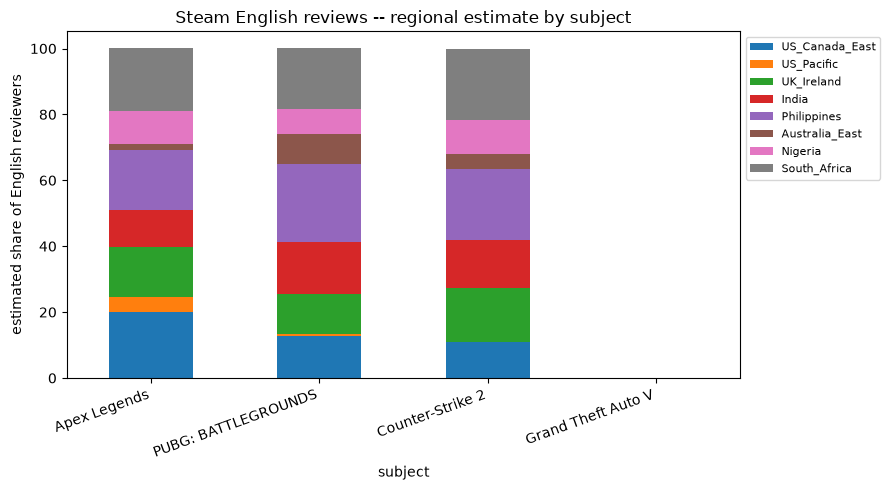

,english_reviews_in_history,total_reviews_crawled,US_Canada_East,US_Pacific,UK_Ireland,India,Philippines,Australia_East,Nigeria,South_Africa
subject,,,,,,,,,,
Apex Legends,179145,591924,20.1,4.6,15.2,11.1,18.3,1.6,10.2,19.1
PUBG: BATTLEGROUNDS,62438,536953,12.8,0.7,11.9,15.9,23.8,8.9,7.7,18.5
Counter-Strike 2,263366,1100240,10.8,0.0,16.5,14.5,21.5,4.8,10.2,21.7
Grand Theft Auto V,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
steam_rows = []
for subject_id in SUBJECT_IDS:
    subject = subjects[subject_id]
    n_reviews = conn.execute(
        "SELECT COUNT(*) FROM steam_review_history WHERE subject_id = ?", (subject_id,)
    ).fetchone()[0]
    hourly = get_steam_review_hourly_series(conn, subject)
    shares = decompose_by_timezone(hourly, calibration_curve=calibration_curve)
    row = {"subject": subject["display_name"], "english_reviews_in_history": int(hourly.sum()), "total_reviews_crawled": n_reviews}
    row.update({country: round(share * 100, 1) for country, share in shares.items()})
    steam_rows.append(row)

steam_df = pd.DataFrame(steam_rows).set_index("subject")

fig, ax = plt.subplots(figsize=(9, 5))
steam_df.drop(columns=["english_reviews_in_history", "total_reviews_crawled"]).fillna(0).plot(kind="bar", stacked=True, ax=ax)
ax.set_ylabel("estimated share of English reviewers")
ax.set_title("Steam English reviews -- regional estimate by subject")
ax.legend(fontsize=8, loc="upper left", bbox_to_anchor=(1.0, 1.0))
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()
steam_df

## Counter-Strike cross-validation

The point of including `counter_strike` here: `notebooks/
fastest_growing_cs_regions.ipynb` already found Russia (accelerating) and
Czech Republic (steady) as genuine grassroots-tournament growers, from
Liquipedia tournament records -- a completely different data source and
method than anything in this notebook. If Steam review-posting-time
(pooled across ALL languages, not just English -- this check is about
the whole playerbase's timing, not the English-speaking slice of it;
`get_steam_review_hourly_series(..., language=None)`) shows the same
Russia/CIS growth shape over the same years, that convergence between
two unrelated methods is real evidence.

**Crawl completed 2026-09-13 (1,100,240 reviews) -- but the result below
cannot actually test the grassroots-growth claim, and that's worth
stating plainly rather than reading too much into what IS there.**
Counter-Strike's crawl reached a much shorter window than Apex/PUBG's --
only 2025-07-14 to now (~14 months), for the same reason those two
notebooks now describe as title-specific and not a fixed depth (see
`notebooks/steam_review_playerbase_over_time.ipynb`'s corrected note --
CS's own crawl actually covered *more* pages and reviews than either of
theirs, just compressed into far less calendar time, consistent with a
much higher review-posting velocity). `fastest_growing_cs_regions.ipynb`'s
finding is a multi-year trend (Russia accelerating across roughly a
decade of grassroots-tournament history) -- 14 months of Steam-review
data cannot confirm or refute a multi-year acceleration claim, full
stop. What the table below CAN show is only whether Russia currently
holds a large, stable share within this short window -- a much weaker
claim than the original cross-validation was scoped for.

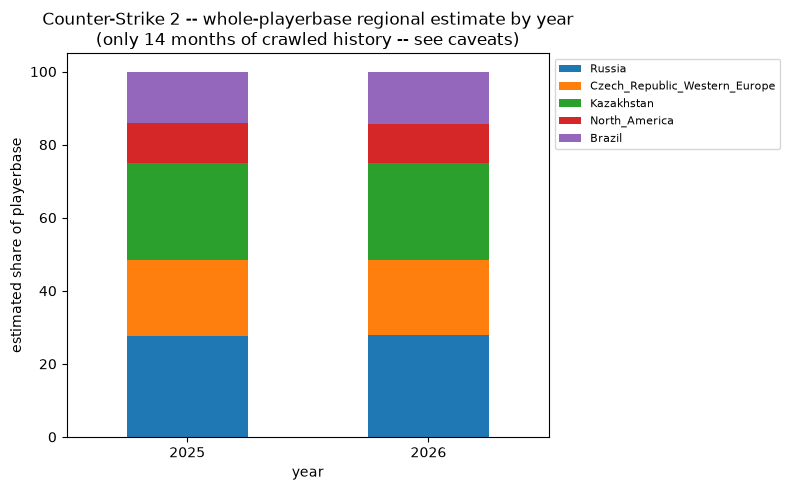

,reviews,Russia,Czech_Republic_Western_Europe,Kazakhstan,North_America,Brazil
year,,,,,,
2025,420077,27.7,20.6,26.8,10.7,14.2
2026,680163,28.0,20.4,26.5,10.8,14.2


In [6]:
# Approximate, non-DST-aware UTC offsets for this specific cross-check --
# not CANDIDATE_ENGLISH_COUNTRIES, since this question is about the whole
# playerbase, not the English-speaking slice. Russia collapsed to one
# offset (Moscow, UTC+3) despite spanning 11 real timezones -- the same
# simplification CALIBRATION_LANGUAGES's own docstring already flags as
# a reason `ru` isn't trusted as a CALIBRATION anchor; here it's a
# decomposition TARGET instead, where that imprecision matters less.
#
# Czech_Republic and Western_Europe merged into one candidate, found
# 2026-09-13: both are UTC+1, genuinely indistinguishable by timezone
# alone -- the same collision bug as CANDIDATE_ENGLISH_COUNTRIES' old
# US_East/Canada_East pair (see analysis/fandom_region_decomposition.py's
# module comment on that fix). Means this section can only speak to
# "Czech Republic and Western Europe combined" vs. the other candidates,
# not Czech Republic specifically -- a real loss of resolution, not
# glossed over.
CS_CANDIDATE_COUNTRIES = {
    "Russia": 3.0,
    "Czech_Republic_Western_Europe": 1.0,
    "Kazakhstan": 5.0,
    "North_America": -6.0,
    "Brazil": -3.0,
}

cs_subject = subjects["counter_strike"]
cs_yearly_rows = []
for year in range(2018, 2027):
    hourly = get_steam_review_hourly_series(conn, cs_subject, language=None, year=year)
    if hourly.sum() == 0:
        continue
    shares = decompose_by_timezone(hourly, CS_CANDIDATE_COUNTRIES, calibration_curve=calibration_curve)
    cs_yearly_rows.append({"year": year, "reviews": int(hourly.sum()), **{k: round(v * 100, 1) for k, v in shares.items()}})

if not cs_yearly_rows:
    print("No Counter-Strike Steam review data yet -- run collectors/steam_review_history_pull.py --subjects counter_strike --refresh first (a long-running background crawl, not a quick command).")
else:
    cs_df = pd.DataFrame(cs_yearly_rows).set_index("year")
    fig, ax = plt.subplots(figsize=(8, 5))
    cs_df.drop(columns="reviews").plot(kind="bar", stacked=True, ax=ax)
    ax.set_ylabel("estimated share of playerbase")
    ax.set_title("Counter-Strike 2 -- whole-playerbase regional estimate by year\n(only 14 months of crawled history -- see caveats)")
    ax.legend(fontsize=8, loc="upper left", bbox_to_anchor=(1.0, 1.0))
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
    display(cs_df)

## Persisting to `english_fandom_region_estimates`

Every share computed above, written to the synthesis table so a future
notebook/query doesn't have to re-derive them — `ai_assisted_unreviewed`
confidence throughout (an inferred estimate, never `verified`, per
CLAUDE.md's provenance rule). `window_start`/`window_end` mark the actual
data window each signal drew from, not today's date.

In [7]:
from datetime import datetime, timezone as tz

computed_at = datetime.now(tz.utc).strftime("%Y-%m-%dT%H:%M:%SZ")


def persist(subject_id, method, signal_source, window_start, window_end, shares):
    for region, share in shares.items():
        conn.execute(
            """
            INSERT INTO english_fandom_region_estimates
                (subject_id, region_or_country, window_start, window_end, method, signal_source, estimated_share, computed_at)
            VALUES (?, ?, ?, ?, ?, ?, ?, ?)
            ON CONFLICT (subject_id, region_or_country, window_start, window_end, method, signal_source)
            DO UPDATE SET estimated_share = excluded.estimated_share, computed_at = excluded.computed_at
            """,
            (subject_id, region, window_start, window_end, method, signal_source, share, computed_at),
        )


rows_persisted = 0
for subject_id in SUBJECT_IDS:
    subject = subjects[subject_id]

    # Twitch timezone deconvolution -- window is language_mix_snapshots'/
    # platform_viewership_snapshots' own actual captured_at range.
    if subject["source_table"] == "viewership_snapshots":
        w = conn.execute("SELECT MIN(captured_at), MAX(captured_at) FROM language_mix_snapshots WHERE title_id = ?", (subject["title_id"],)).fetchone()
    else:
        w = conn.execute("SELECT MIN(captured_at), MAX(captured_at) FROM platform_viewership_snapshots WHERE game_id = ?", (subject["game_id"],)).fetchone()
    if w[0]:
        hourly = get_twitch_english_hourly_series(conn, subject)
        shares = decompose_by_timezone(hourly, calibration_curve=calibration_curve)
        persist(subject_id, "timezone_deconvolution", "twitch_viewership", w[0], w[1], shares)
        rows_persisted += len(shares)

    # Tag mining -- normalized to a share of THIS subject's own tagged rows.
    row = next((r for r in tag_rows if r["subject"] == subject["display_name"]), None)
    if row:
        tag_counts = {k: v for k, v in row.items() if k != "subject" and v}
        total = sum(tag_counts.values())
        if total > 0 and w[0]:
            persist(subject_id, "tag_mining", "twitch_viewership", w[0], w[1], {k: v / total for k, v in tag_counts.items()})
            rows_persisted += len(tag_counts)

    # Steam review timezone deconvolution (English-only, matching Signal 4).
    ws = conn.execute("SELECT MIN(timestamp_created), MAX(timestamp_created) FROM steam_review_history WHERE subject_id = ? AND language = 'english'", (subject_id,)).fetchone()
    if ws[0]:
        window_start = datetime.fromtimestamp(ws[0], tz=tz.utc).strftime("%Y-%m-%dT%H:%M:%SZ")
        window_end = datetime.fromtimestamp(ws[1], tz=tz.utc).strftime("%Y-%m-%dT%H:%M:%SZ")
        hourly = get_steam_review_hourly_series(conn, subject)
        shares = decompose_by_timezone(hourly, calibration_curve=calibration_curve)
        persist(subject_id, "timezone_deconvolution", "steam_reviews", window_start, window_end, shares)
        rows_persisted += len(shares)

# Counter-Strike yearly cross-validation, one row-set per year.
for entry in cs_yearly_rows:
    year = entry["year"]
    window_start, window_end = f"{year}-01-01T00:00:00Z", f"{year}-12-31T23:59:59Z"
    shares = {k: v / 100 for k, v in entry.items() if k not in ("year", "reviews")}
    persist("counter_strike", "timezone_deconvolution", "steam_reviews", window_start, window_end, shares)
    rows_persisted += len(shares)

conn.commit()
print(f"persisted {rows_persisted} estimate row(s) to english_fandom_region_estimates")

persisted 91 estimate row(s) to english_fandom_region_estimates


## Caveats -- read everything above as directional, not settled

- **Twitch English-viewer-time deconvolution** rests on a calibration
  curve built from only two languages (`ja`, `ko`) over the same short
  window every other notebook in this project already flags as a ~2-week
  snapshot, not a seasonally-averaged baseline. Re-run once
  `language_mix_snapshots` has months of history.
- **All UTC offsets are fixed, non-DST-aware nominal values** (module
  docstring) -- a real, stated simplification, not a silently-assumed
  one.
- **Self-declared region tags are sparse by design** -- most streams
  carry no region marker at all; a subject with very few tagged streams
  should not be read as "has no international audience," only as
  "few streamers self-declared one."
- **Wikipedia pageviews cannot be timezone-deconvolved** (daily
  granularity only, confirmed against the live API while building this
  notebook) -- shown as an independent trend signal, not a region input.
- **Steam reviews are not a random sample, in either dimension --
  checked directly, not assumed.** Time: the crawl is a deterministic,
  most-recent-first walk that stops at a real, documented Steam
  cursor-pagination limit, not a sample spread across a title's whole
  history -- confirmed the reached window has zero gap days for all
  three crawled subjects, so it's a complete census of that period, then
  a hard cliff to nothing before it. Population: reviewers are
  self-selected (more-engaged players review more, sentiment is
  bimodal, review-prompt UI and regional norms can skew who shows up) --
  never "a random sample of who plays this game." Full detail in
  `analysis/fandom_region_decomposition.py`'s own module docstring.
- **The reached crawl window varies by title and is NOT a fixed
  constant** (corrected 2026-09-13, see `notebooks/
  steam_review_playerbase_over_time.ipynb`) -- Counter-Strike's crawl
  reached only ~14 months of history despite the most pages/reviews of
  the three crawled titles, apparently because of its own much higher
  review-posting velocity, not a shared depth ceiling. Check
  `MIN(timestamp_created)` per subject before treating any date range as
  given.
- **The Counter-Strike cross-validation cannot actually confirm or
  refute `fastest_growing_cs_regions.ipynb`'s multi-year finding** --
  its 14-month window is too short to show year-over-year acceleration.
  See that section's own note.